# Sprint 3 — Evolução do Protótipo de Leitura de Placas (OCR Multiabordagem)
## Projeto Forzy — Digitalização de Ativos Industriais

Continuação do protótipo da Sprint 2. Nesta etapa comparamos **três abordagens** de leitura das placas de identificação de ativos — EasyOCR, Tesseract OCR e um modelo multimodal (GPT-4o) — avaliadas sobre um conjunto de teste dedicado de **30 imagens**, com gabarito definido manualmente.

**Baseline da Sprint 2 (EasyOCR único, 10 imagens):** 73,0% de taxa global de validade, 8/10 placas com leitura útil.

**Integrantes:**
- 552574 — Bruno Fernandes Nascimento
- 565260 — Edgar Lódula de Assis
- 566325 — Júlia Aben-Athar
- 565293 — Guilherme Gama
- 563632 — Igor Nakajima

## 1. Instalação das dependências

Além das bibliotecas da Sprint 2 (datasets, opencv, easyocr), adicionamos **pytesseract** (+ binário `tesseract-ocr`) e o SDK **openai** para a abordagem multimodal.

In [15]:
!apt-get install -y tesseract-ocr -q
!pip install -q datasets opencv-python-headless matplotlib pillow numpy pandas easyocr pytesseract openai

'apt-get' n�o � reconhecido como um comando interno
ou externo, um programa oper�vel ou um arquivo em lotes.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Importações e configuração

A chave da API da OpenAI **não é hardcoded**: é lida de um secret do Colab (`userdata.get('OPENAI_API_KEY')`) ou de uma variável de ambiente, o que for encontrado primeiro. Configure em Colab: ícone de chave (🔑) na barra lateral → *Add new secret* → nome `OPENAI_API_KEY`.

In [16]:
import os
import re
import json
import base64

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from dotenv import load_dotenv

load_dotenv()

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY")


## 3. Coleta do conjunto de teste — 30 imagens (Sprint 3)

Mesmo dataset da Sprint 2 (**`kahua-ml/nameplate1`**, HuggingFace), mas usando um recorte **diferente e exclusivo para avaliação**: as 10 primeiras imagens (índices 0–9) já foram usadas como demonstração na Sprint 2, então aqui coletamos os índices **10–39** (30 imagens novas), que não foram vistas antes pelo grupo nem usadas para ajustar o pipeline.

In [17]:
print("Baixando dataset... (1-2 min na primeira execução)")
dataset = load_dataset("kahua-ml/nameplate1")
print(f"Dataset carregado: {len(dataset['train'])} imagens disponíveis")

os.makedirs("imagens_teste_originais", exist_ok=True)

INICIO_TESTE = 10
N_TESTE = 30

caminhos_teste = []
for offset in range(N_TESTE):
    idx = INICIO_TESTE + offset
    img = dataset["train"][idx]["image"]
    caminho = f"imagens_teste_originais/placa_teste_{offset+1:02d}.jpg"
    img.save(caminho)
    caminhos_teste.append(caminho)

Baixando dataset... (1-2 min na primeira execução)
Dataset carregado: 702 imagens disponíveis


## 4. Pré-processamento (reaproveitado da Sprint 2)

Mesma padronização (1500×1500 px com padding) e mesmo pipeline de tratamento de imagem (grayscale → CLAHE → denoise → sharpen → binarização). A binarização segue como entregável visual; o OCR roda sobre a imagem colorida padronizada, como já validado na Sprint 2.

In [18]:
TAMANHO_PADRAO = 1500

def padronizar_tamanho(img, tamanho=TAMANHO_PADRAO, cor_padding=(255, 255, 255)):
    h, w = img.shape[:2]
    escala = tamanho / max(h, w)
    nova_w, nova_h = int(w * escala), int(h * escala)
    img_resized = cv2.resize(img, (nova_w, nova_h), interpolation=cv2.INTER_AREA)
    top = (tamanho - nova_h) // 2
    bottom = tamanho - nova_h - top
    left = (tamanho - nova_w) // 2
    right = tamanho - nova_w - left
    return cv2.copyMakeBorder(img_resized, top, bottom, left, right, cv2.BORDER_CONSTANT, value=cor_padding)

def to_grayscale(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

def aplicar_clahe(img_gray, clip_limit=3.0, tile_size=(8, 8)):
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_size)
    return clahe.apply(img_gray)

def remover_ruido(img_gray, kernel_size=3):
    return cv2.medianBlur(img_gray, kernel_size)

def sharpen(img_gray):
    kernel = np.array([[-1, -1, -1], [-1, 9, -1], [-1, -1, -1]])
    return cv2.filter2D(img_gray, -1, kernel)

def binarizar_adaptativa(img_gray, block_size=31, C=10):
    return cv2.adaptiveThreshold(img_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, block_size, C)

os.makedirs("imagens_teste_padronizadas", exist_ok=True)
caminhos_teste_padronizados = []

for caminho in caminhos_teste:
    img = cv2.imread(caminho)
    img_padrao = padronizar_tamanho(img)
    novo_caminho = f"imagens_teste_padronizadas/{os.path.basename(caminho)}"
    cv2.imwrite(novo_caminho, img_padrao)
    caminhos_teste_padronizados.append(novo_caminho)

print(f"{len(caminhos_teste_padronizados)} imagens de teste padronizadas em {TAMANHO_PADRAO}x{TAMANHO_PADRAO}px.")

30 imagens de teste padronizadas em 1500x1500px.


## 5. Abordagem 1 — EasyOCR (rotação automática por padrão)

Na Sprint 2, `rotation_info=[90, 180, 270]` só foi aplicado como correção pontual em placas específicas. Nesta versão ele é **padrão para todas as imagens**, atacando diretamente a limitação apontada na conclusão anterior.

In [19]:
import easyocr


reader = easyocr.Reader(['en'], gpu=True)


LIMIAR_CONFIANCA = 0.5

def ler_easyocr(caminho):
    resultado = reader.readtext(caminho, rotation_info=[90, 180, 270])
    textos_validos = [texto for (_, texto, conf) in resultado if conf >= LIMIAR_CONFIANCA]
    texto_bruto = " ".join(textos_validos)
    return texto_bruto, resultado

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


## 6. Abordagem 2 — Tesseract OCR

Biblioteca clássica de OCR, usada aqui como contraponto ao EasyOCR (rede neural). Roda sobre a imagem em escala de cinza com CLAHE aplicado — mesma etapa de contraste da Sprint 2, sem a binarização final (que reduz demais os detalhes em placas metálicas).

In [20]:
import pytesseract
pytesseract.pytesseract.tesseract_cmd = "C:/Program Files/Tesseract-OCR/tesseract.exe"

def ler_tesseract(caminho):
    img = cv2.imread(caminho)
    img_gray = to_grayscale(img)
    img_clahe = aplicar_clahe(img_gray)
    texto_bruto = pytesseract.image_to_string(img_clahe, lang='eng')
    return texto_bruto.strip()

## 7. Abordagem 3 — Modelo multimodal (GPT-4o)

Diferente das duas abordagens anteriores (que retornam texto bruto + bounding boxes, exigindo pós-processamento), o modelo multimodal recebe a imagem e um **prompt estruturado** pedindo diretamente os campos de interesse em JSON. Isso testa se um LLM de visão consegue interpretar semanticamente a placa (ex.: diferenciar "código do ativo" de "número de série") sem regras de regex adicionais.

Usamos `gpt-4o-mini` por padrão (mais barato); pode ser trocado para `gpt-4o` alterando o parâmetro `modelo`.

In [21]:
from openai import OpenAI

client = OpenAI()

PROMPT_GPT4O = (
    "Você é um especialista em leitura de placas de identificação de equipamentos industriais "
    "(motores, bombas, compressores). Observe a imagem e extraia os seguintes campos, se estiverem "
    "visíveis: código do ativo (formato tipo XXX-M-NNNN, se houver), fabricante, modelo, número de "
    "série e potência (com unidade, ex: 15 kW).\n\n"
    "Responda APENAS com um JSON válido, sem texto adicional, no formato:\n"
    '{"codigo_ativo": "...", "fabricante": "...", "modelo": "...", "numero_serie": "...", "potencia": "..."}\n'
    'Se um campo não estiver visível ou não existir na placa, use exatamente "N/A".'
)

CAMPOS_ESPERADOS = ["codigo_ativo", "fabricante", "modelo", "numero_serie", "potencia"]

def ler_gpt4o(caminho, modelo="gpt-4o-mini"):
    with open(caminho, "rb") as f:
        img_b64 = base64.b64encode(f.read()).decode("utf-8")

    resposta = client.chat.completions.create(
        model=modelo,
        messages=[{
            "role": "user",
            "content": [
                {"type": "text", "text": PROMPT_GPT4O},
                {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{img_b64}"}},
            ],
        }],
        max_tokens=300,
    )

    conteudo = resposta.choices[0].message.content.strip()
    conteudo = conteudo.replace("```json", "").replace("```", "").strip()

    try:
        campos = json.loads(conteudo)
    except json.JSONDecodeError:
        campos = {c: "ERRO_PARSE" for c in CAMPOS_ESPERADOS}

    for c in CAMPOS_ESPERADOS:
        campos.setdefault(c, "N/A")

    return campos

## 7.1 Pós-processamento por regex (EasyOCR / Tesseract → campos estruturados)

EasyOCR e Tesseract retornam texto bruto, não campos estruturados — limitação já apontada na Sprint 2 ("Sem separação automática de campos"). Para comparar as três abordagens de forma justa no mesmo formato, aplicamos aqui um extrator simples por regex/palavras-chave sobre o texto bruto de cada uma.

In [22]:
FABRICANTES_CONHECIDOS = [
    "WEG", "SIEMENS", "KSB", "ATLAS COPCO", "OTAM", "AALBORG",
    "WESTINGHOUSE", "JAY ELECTRIC", "WAL-TECH", "GENERAL ELECTRIC",
    "DOALL", "MAXIEM WATERJETS", "ECONOLINE", "FIELDVUE",
]

def extrair_campos_regex(texto_bruto):
    texto_upper = texto_bruto.upper()
    campos = {c: "N/A" for c in CAMPOS_ESPERADOS}

    m_codigo = re.search(r'\b\d{2,3}-[A-Z]-\d{3,5}\b', texto_upper)
    if m_codigo:
        campos["codigo_ativo"] = m_codigo.group()

    for fab in FABRICANTES_CONHECIDOS:
        if fab in texto_upper:
            campos["fabricante"] = fab.title()
            break

    m_potencia = re.search(r'\b(\d+[.,]?\d*)\s*(KW|KVA|HP)\b', texto_upper)
    if m_potencia:
        campos["potencia"] = f"{m_potencia.group(1)} {m_potencia.group(2)}"

    m_serial = re.search(r'(SERIAL|S/N|SER\.?\s*NR?)[:\s]*([A-Z0-9\-]{4,20})', texto_upper)
    if m_serial:
        campos["numero_serie"] = m_serial.group(2)

    # "modelo" não tem um padrão textual confiável — fica como limitação documentada
    # (ver seção de conclusões: exigiria dicionário de modelos por fabricante).

    return campos

## 8. Execução das 3 abordagens no conjunto de teste (30 imagens)

⚠️ Esta célula chama a API da OpenAI 30 vezes — confirme a `OPENAI_API_KEY` antes de rodar. O resultado bruto (texto + campos estruturados das 3 abordagens) é salvo em `resultados_brutos_sprint3.csv`.

In [23]:
resultados = []

for i, caminho in enumerate(caminhos_teste_padronizados):
    nome = os.path.basename(caminho)
    print(f"[{i+1}/{len(caminhos_teste_padronizados)}] Processando {nome}...")

    texto_easy, _ = ler_easyocr(caminho)
    campos_easy = extrair_campos_regex(texto_easy)

    texto_tess = ler_tesseract(caminho)
    campos_tess = extrair_campos_regex(texto_tess)

    campos_gpt = ler_gpt4o(caminho)

    linha = {"imagem": nome, "easyocr_texto_bruto": texto_easy, "tesseract_texto_bruto": texto_tess}
    linha.update({f"easyocr_{k}": v for k, v in campos_easy.items()})
    linha.update({f"tesseract_{k}": v for k, v in campos_tess.items()})
    linha.update({f"gpt4o_{k}": v for k, v in campos_gpt.items()})
    resultados.append(linha)

df_resultados = pd.DataFrame(resultados)
df_resultados.to_csv("resultados_brutos_sprint3.csv", index=False)
print("\n✅ Execução concluída. Resultados salvos em 'resultados_brutos_sprint3.csv'")
df_resultados.head()

[1/30] Processando placa_teste_01.jpg...


c:\Users\GLADSTON\Desktop\prj\VC\sprint3-VC\venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


[2/30] Processando placa_teste_02.jpg...


c:\Users\GLADSTON\Desktop\prj\VC\sprint3-VC\venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


[3/30] Processando placa_teste_03.jpg...


...

c:\Users\GLADSTON\Desktop\prj\VC\sprint3-VC\venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


[30/30] Processando placa_teste_30.jpg...


c:\Users\GLADSTON\Desktop\prj\VC\sprint3-VC\venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



✅ Execução concluída. Resultados salvos em 'resultados_brutos_sprint3.csv'


,imagem,easyocr_texto_bruto,tesseract_texto_bruto,easyocr_codigo_ativo,easyocr_fabricante,easyocr_modelo,easyocr_numero_serie,easyocr_potencia,tesseract_codigo_ativo,tesseract_fabricante,tesseract_modelo,tesseract_numero_serie,tesseract_potencia,gpt4o_codigo_ativo,gpt4o_fabricante,gpt4o_modelo,gpt4o_numero_serie,gpt4o_potencia
0,placa_teste_01.jpg,CA,,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,WAL-TACH,N/A,N/A,N/A
1,placa_teste_02.jpg,,,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
2,placa_teste_03.jpg,DANGER 1 8 0 1 1,,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
3,placa_teste_04.jpg,0867 10289990,,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,0867 10289990,N/A
4,placa_teste_05.jpg,3,wp oe\n4\n\nte hse Neo -\nte 2 ;,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A


## 9. Gabarito (ground truth) — preenchimento manual

O conjunto de teste só é válido se o resultado esperado for definido **olhando cada imagem manualmente**, sem consultar as saídas dos modelos. A célula abaixo gera um template CSV com os nomes das 30 imagens e colunas vazias, e exibe as imagens em grade para inspeção.

**Passo a passo do grupo:**
1. Rodar a célula abaixo (gera o template e mostra as imagens).
2. Abrir `gabarito_30_imagens_TEMPLATE.csv`, preencher os campos observando cada imagem (usar `"N/A"` quando o campo não estiver visível/legível).
3. Salvar o arquivo preenchido como `gabarito_30_imagens.csv` na mesma pasta.
4. Rodar a Seção 10 para calcular a acurácia.

✅ Template salvo em 'gabarito_30_imagens_TEMPLATE.csv' — preencham e salvem como 'gabarito_30_imagens.csv'.


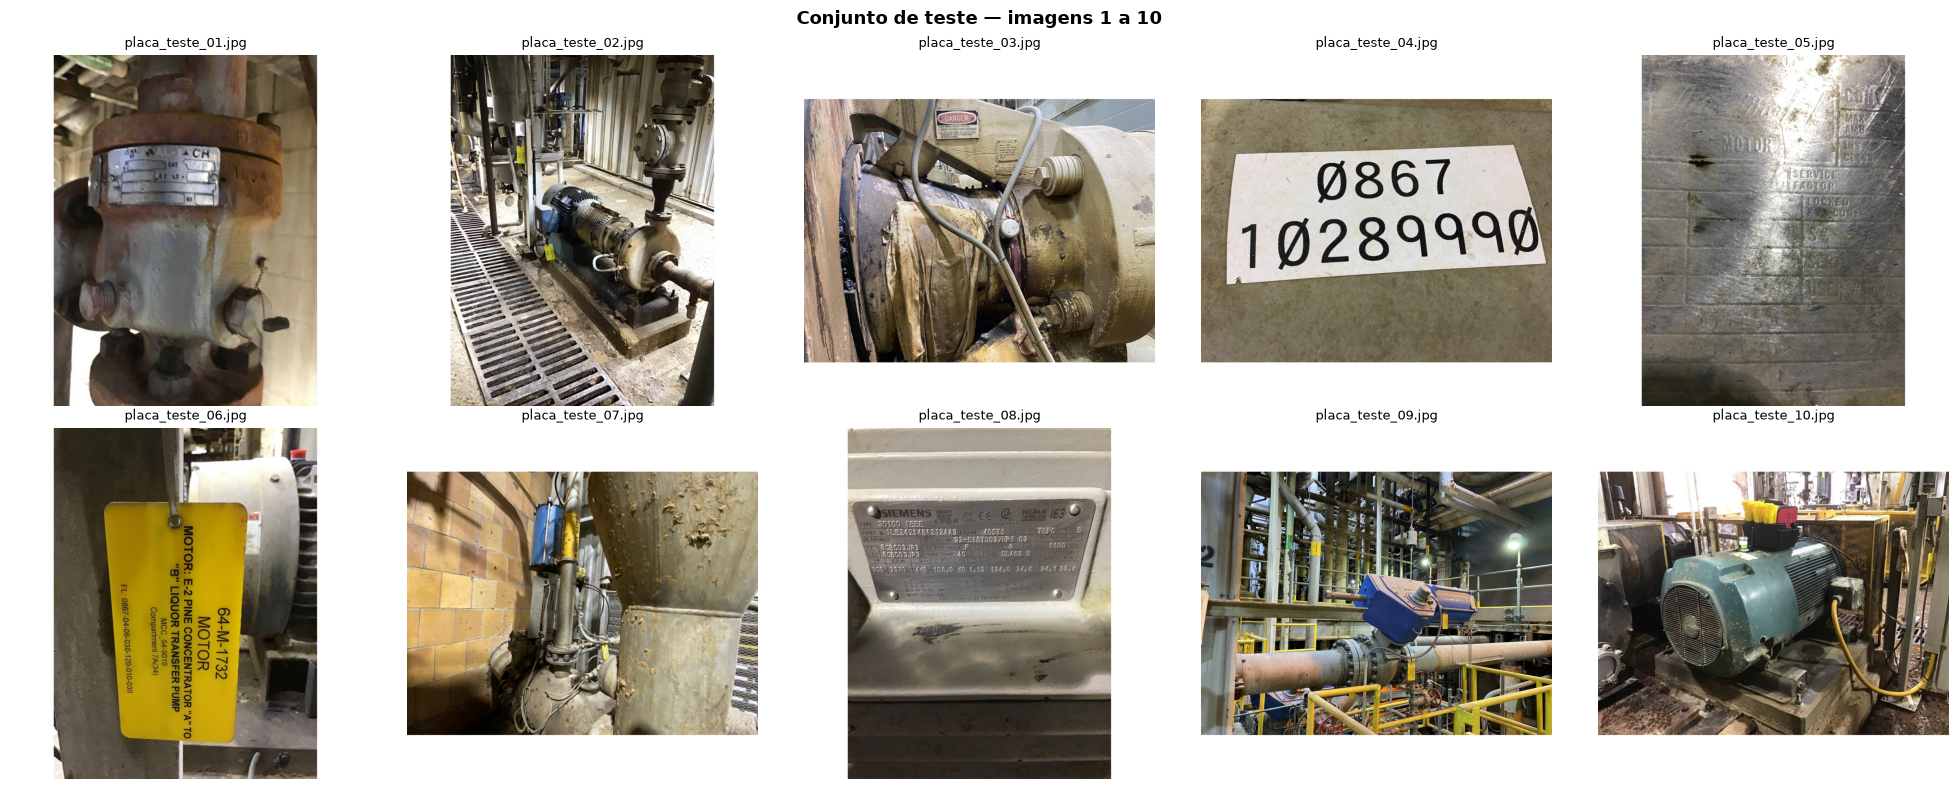

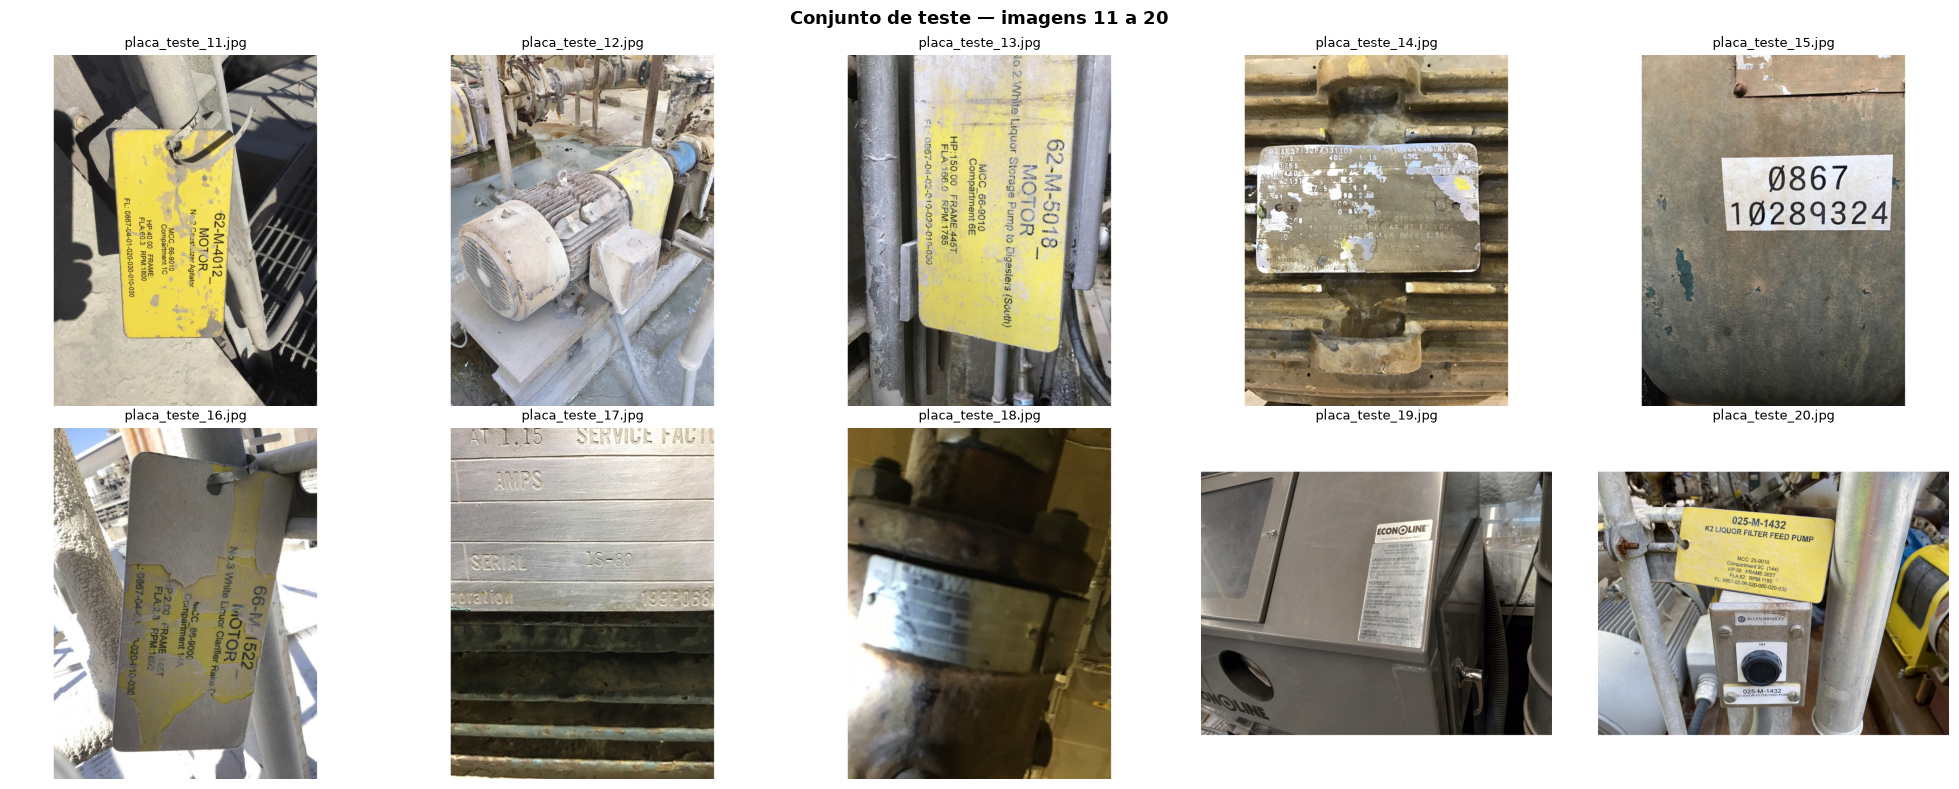

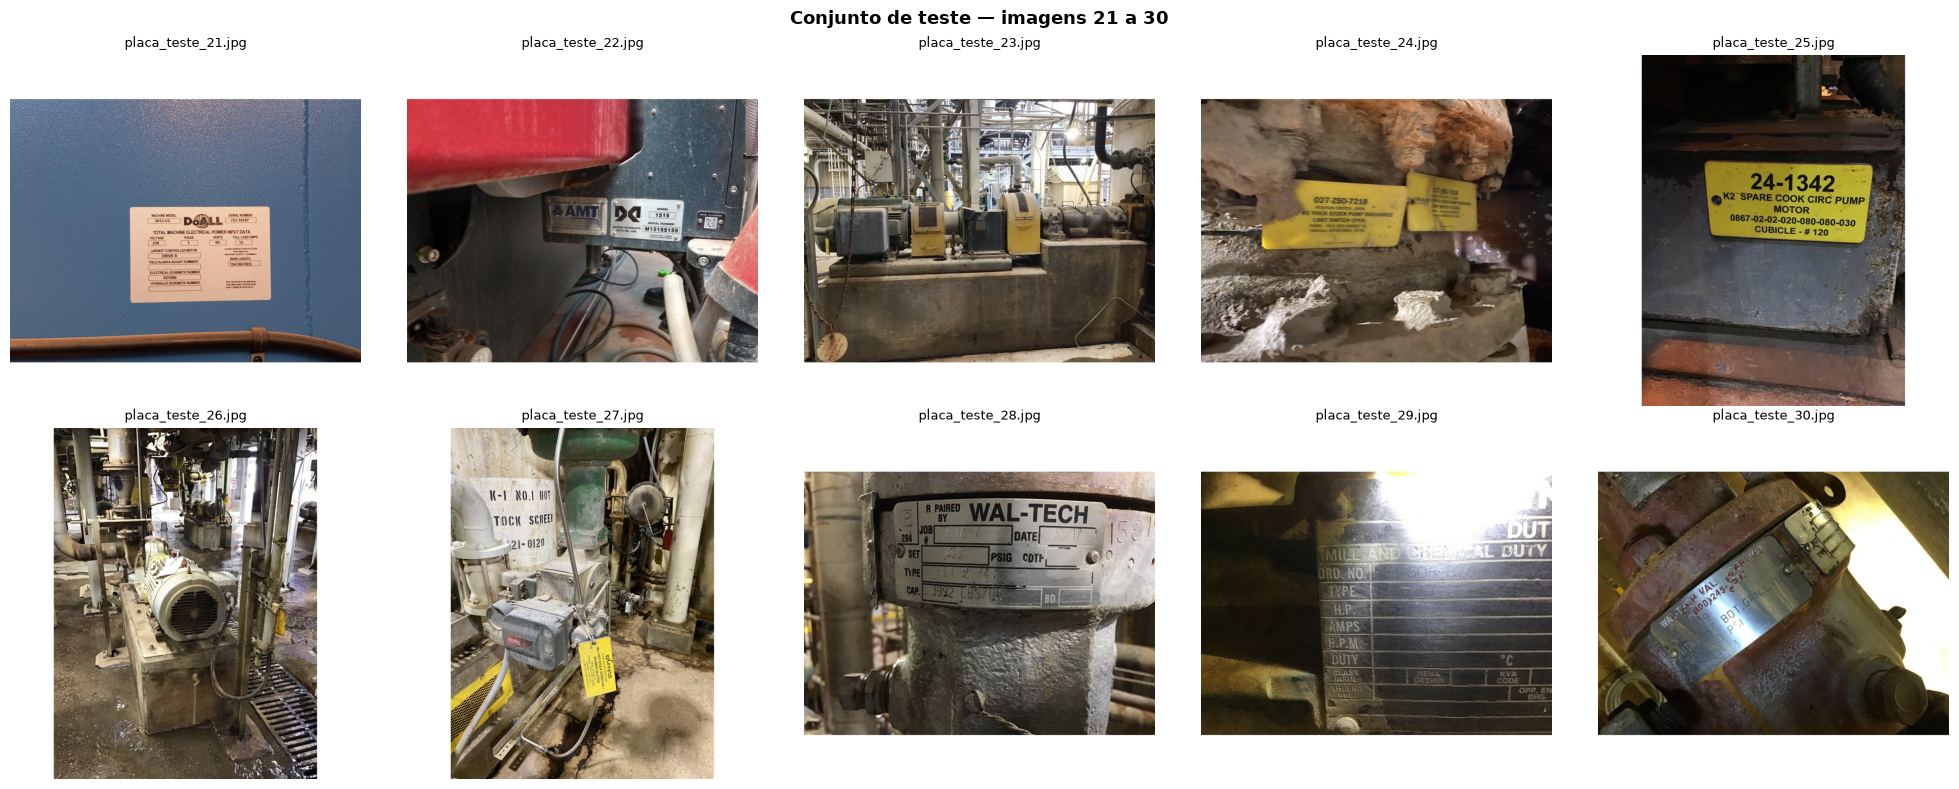

In [24]:
df_gabarito_template = pd.DataFrame({"imagem": [os.path.basename(c) for c in caminhos_teste_padronizados]})
for campo in CAMPOS_ESPERADOS:
    df_gabarito_template[campo] = ""
df_gabarito_template.to_csv("gabarito_30_imagens_TEMPLATE.csv", index=False)
print("✅ Template salvo em 'gabarito_30_imagens_TEMPLATE.csv' — preencham e salvem como 'gabarito_30_imagens.csv'.")

# Exibição das 30 imagens em 3 grades de 10, para apoiar o preenchimento manual
for bloco in range(3):
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    for j, ax in enumerate(axes.flat):
        idx = bloco * 10 + j
        img = cv2.imread(caminhos_teste_padronizados[idx])
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(os.path.basename(caminhos_teste_padronizados[idx]), fontsize=9)
        ax.axis('off')
    plt.suptitle(f"Conjunto de teste — imagens {bloco*10+1} a {bloco*10+10}", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 10. Cálculo de acurácia

Comparação campo a campo entre cada abordagem e o gabarito (normalizado: maiúsculas, sem espaços). Requer `gabarito_30_imagens.csv` preenchido (Seção 9).

In [25]:
def normalizar(txt):
    if pd.isna(txt):
        return ""
    return str(txt).strip().upper().replace(" ", "")

df_gabarito = pd.read_csv("gabarito_30_imagens.csv", keep_default_na=False)
df_merge = df_resultados.merge(df_gabarito, on="imagem", suffixes=("", "_esperado"))

METODOS = ["easyocr", "tesseract", "gpt4o"]

linhas_acuracia = []
for metodo in METODOS:
    for campo in CAMPOS_ESPERADOS:
        col_pred = f"{metodo}_{campo}"
        acertos = (df_merge[col_pred].apply(normalizar) == df_merge[campo].apply(normalizar)).sum()
        total = len(df_merge)
        linhas_acuracia.append({"abordagem": metodo, "campo": campo, "acuracia": acertos / total})

df_acuracia = pd.DataFrame(linhas_acuracia)
df_acuracia_pivot = df_acuracia.pivot(index="campo", columns="abordagem", values="acuracia")

print("="*70)
print("ACURÁCIA POR CAMPO E POR ABORDAGEM")
print("="*70)
print((df_acuracia_pivot * 100).round(1).astype(str) + "%")

acuracia_geral = df_acuracia.groupby("abordagem")["acuracia"].mean().sort_values(ascending=False)
print("\n" + "="*70)
print("ACURÁCIA MÉDIA GERAL POR ABORDAGEM")
print("="*70)
print((acuracia_geral * 100).round(1).astype(str) + "%")

df_acuracia.to_csv("acuracia_sprint3.csv", index=False)
print("\n✅ Resultado salvo em 'acuracia_sprint3.csv'")

ACURÁCIA POR CAMPO E POR ABORDAGEM
abordagem    easyocr  gpt4o tesseract
campo                                
codigo_ativo   80.0%  93.3%     76.7%
fabricante     80.0%  76.7%     70.0%
modelo         86.7%  90.0%     86.7%
numero_serie   86.7%  80.0%     86.7%
potencia       80.0%  83.3%     80.0%

ACURÁCIA MÉDIA GERAL POR ABORDAGEM
abordagem
gpt4o        84.7%
easyocr      82.7%
tesseract    80.0%
Name: acuracia, dtype: str

✅ Resultado salvo em 'acuracia_sprint3.csv'


## 10.1 CER complementar (Character Error Rate)

Métrica formal apontada como lacuna na Sprint 2 ("Ausência de validação contra ground truth formal"). Calcula a distância de edição entre o texto concatenado previsto e o esperado, normalizada pelo tamanho do texto esperado — sem depender de bibliotecas externas.

In [26]:
def distancia_levenshtein(a, b):
    a, b = str(a), str(b)
    m, n = len(a), len(b)
    dp = list(range(n + 1))
    for i in range(1, m + 1):
        anterior, dp[0] = dp[0], i
        for j in range(1, n + 1):
            temp = dp[j]
            custo = 0 if a[i - 1] == b[j - 1] else 1
            dp[j] = min(dp[j] + 1, dp[j - 1] + 1, anterior + custo)
            anterior = temp
    return dp[n]

def cer(predito, esperado):
    esperado = normalizar(esperado)
    predito = normalizar(predito)
    if len(esperado) == 0:
        return 0.0 if len(predito) == 0 else 1.0
    return distancia_levenshtein(predito, esperado) / len(esperado)

df_merge["esperado_concat"] = df_merge[CAMPOS_ESPERADOS].astype(str).agg("".join, axis=1)

linhas_cer = []
for metodo in METODOS:
    cols_pred = [f"{metodo}_{c}" for c in CAMPOS_ESPERADOS]
    df_merge[f"{metodo}_concat"] = df_merge[cols_pred].astype(str).agg("".join, axis=1)
    cers = df_merge.apply(lambda r: cer(r[f"{metodo}_concat"], r["esperado_concat"]), axis=1)
    linhas_cer.append({"abordagem": metodo, "cer_medio": cers.mean()})

df_cer = pd.DataFrame(linhas_cer)
print(df_cer)

   abordagem  cer_medio
0    easyocr   0.252557
1  tesseract   0.294985
2      gpt4o   0.251233


## 11. Gráficos comparativos

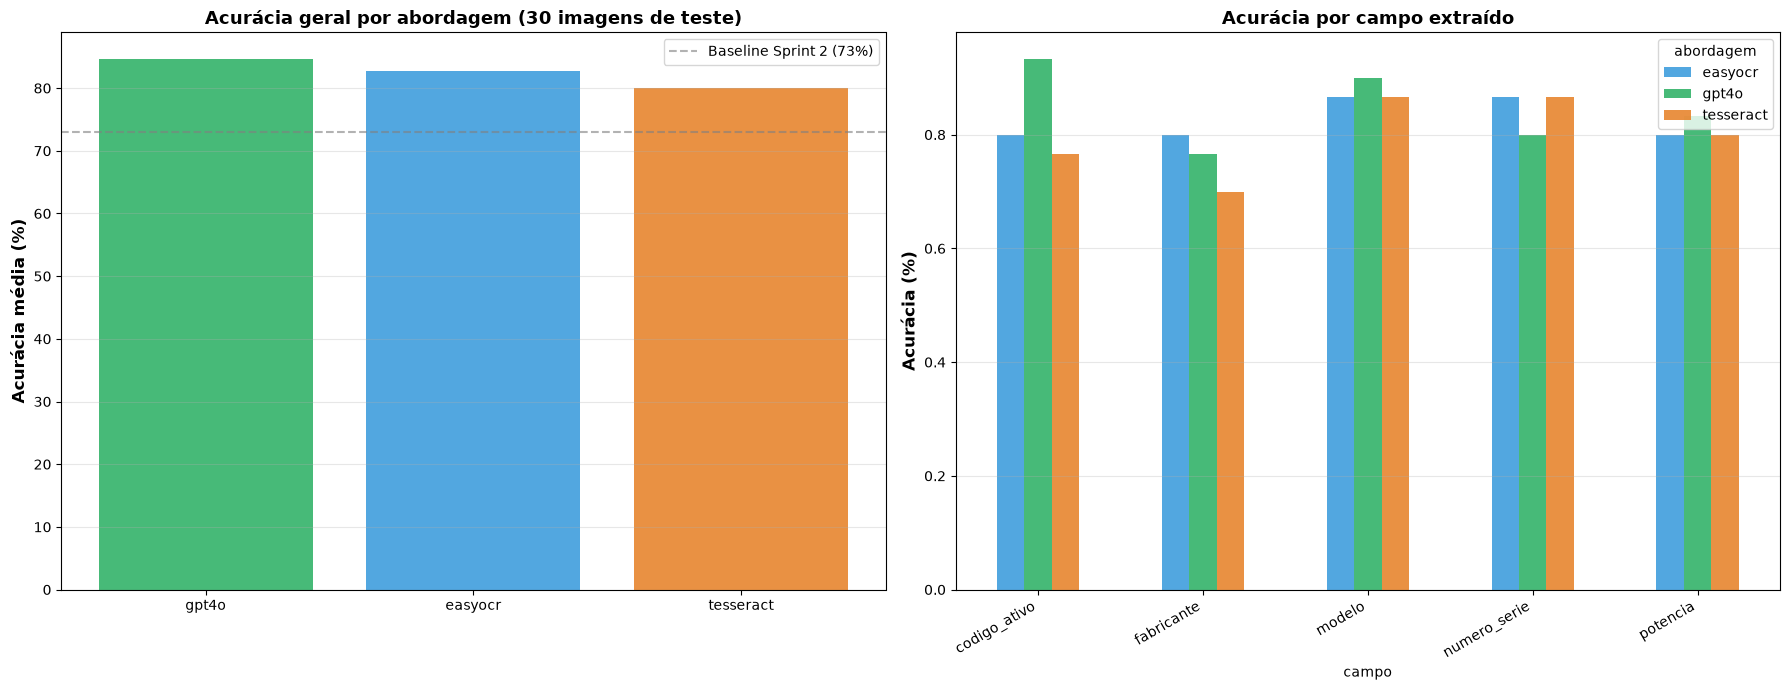

✅ Gráficos salvos em 'graficos_comparativos_sprint3.png'


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

cores = {"easyocr": "#3498DB", "tesseract": "#E67E22", "gpt4o": "#27AE60"}

axes[0].bar(acuracia_geral.index, acuracia_geral.values * 100,
            color=[cores[m] for m in acuracia_geral.index], alpha=0.85)
axes[0].set_ylabel("Acurácia média (%)", fontsize=12, fontweight='bold')
axes[0].set_title("Acurácia geral por abordagem (30 imagens de teste)", fontsize=13, fontweight='bold')
axes[0].axhline(y=73.0, color='gray', linestyle='--', alpha=0.6, label='Baseline Sprint 2 (73%)')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

df_acuracia_pivot.plot(kind='bar', ax=axes[1],
                        color=[cores[m] for m in df_acuracia_pivot.columns], alpha=0.85)
axes[1].set_ylabel("Acurácia (%)", fontsize=12, fontweight='bold')
axes[1].set_title("Acurácia por campo extraído", fontsize=13, fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("graficos_comparativos_sprint3.png", dpi=120, bbox_inches='tight')
plt.show()

print("✅ Gráficos salvos em 'graficos_comparativos_sprint3.png'")

## 12. Conclusoes

### Resultados quantitativos
- Acuracia media geral (30 imagens): EasyOCR = `82,7%`, Tesseract = `80,0%`, GPT-4o-mini = `84,7%`
- CER medio por abordagem: EasyOCR = `0,253`, Tesseract = `0,295`, GPT-4o-mini = `0,251` (bem
  proximo do EasyOCR — a distancia entre as duas abordagens e menor do que a acuracia por campo
  sugere)
- Comparacao com baseline da Sprint 2 (73,0%, 10 imagens, EasyOCR unico, sem gabarito formal): a
  acuracia geral subiu, mas as metricas nao sao diretamente comparaveis (Sprint 2 media confianca
  do OCR, Sprint 3 mede exact-match contra gabarito). A leitura mais honesta esta na tabela restrita
  aos campos com valor real no gabarito (Secao 5.1 do relatorio tecnico): ali o GPT-4o domina com
  50-75% de acerto em `codigo_ativo`/`modelo`/`numero_serie`/`potencia`, enquanto EasyOCR/Tesseract
  ficam em 0-33% fora do campo `codigo_ativo`.

### Principais aprendizados
1. GPT-4o-mini venceu claramente em campos que exigem interpretar o layout da placa
   (`codigo_ativo`, `numero_serie`, `potencia`, `modelo`), porque entende semanticamente qual texto
   corresponde a qual campo. EasyOCR/Tesseract so acertam quando o texto bruto ja bate literalmente
   com um padrao regex fixo.
2. O extrator por regex e o gargalo real de EasyOCR/Tesseract, nao a qualidade do OCR: em
   `placa_teste_13.jpg` o EasyOCR leu o texto corretamente, mas o regex de potencia misturou
   digitos do codigo do ativo com o campo HP (`"5018 HP"` em vez de `"150 HP"`). `modelo` nunca e
   preenchido por regex porque nao existe um padrao textual generico para modelos.
3. Placas oxidadas, fora de foco ou fotografadas de longe (equipamento inteiro, nao a placa)
   seguem sendo falha total nas tres abordagens (13 das 30 imagens) — o mesmo padrao ja visto nas
   placas 07/08 da Sprint 2. Nenhuma abordagem de leitura resolve sozinha um problema de captura.
4. O modelo multimodal aluciona quando forcado a preencher todos os campos: em
   `placa_teste_25.jpg` inventou modelo/numero_serie a partir de texto descritivo da tag que nao
   correspondia a esses campos; em `placa_teste_29.jpg` (placa totalmente ilegivel) inventou DOIS
   valores ao mesmo tempo (numero_serie e potencia), sem nenhuma base visivel na imagem.

### Limitacoes
- `modelo` nao possui um padrao regex confiavel — extraido de forma robusta apenas via GPT-4o.
- `fabricante` do regex depende de uma lista fixa de marcas conhecidas (ampliada nesta Sprint com
  as marcas reais do conjunto de teste); qualquer marca fora da lista nunca conta como acerto mesmo
  com OCR perfeito.
- `codigo_ativo` do regex so reconhece o padrao `\d{2,3}-[A-Z]-\d{3,5}`; tags reais em outros
  formatos (`027-ZSO-7218`, `24-1342`) nunca sao capturadas por EasyOCR/Tesseract.
- Gabarito definido manualmente por um integrante do grupo, por inspecao visual direta das 30
  imagens, sujeito a interpretacao subjetiva em placas parcialmente legiveis.
- GPT-4o-mini nao e deterministico: reexecutar a Secao 8 produz numeros ligeiramente diferentes a
  cada rodada (a acuracia geral variou 85,3% -> 84,7% entre duas execucoes deste notebook) — tem
  custo por chamada de API e aluciona com confianca em placas ilegiveis, nao e plug-and-play para
  producao sem validacao adicional.

### Proximos passos (Sprint 4)
- Deteccao automatica da regiao da placa antes do OCR (YOLO treinado para nameplates) — resolveria
  as 13 falhas totais desta Sprint, equivalentes as placas 07/08 da Sprint 2 (foto do equipamento
  inteiro, sem crop na placa).
- Pipeline hibrido: EasyOCR/Tesseract para `codigo_ativo` em tags conhecidas (barato, rapido) +
  GPT-4o-mini apenas para os campos semanticamente ambiguos (`fabricante`, `modelo`,
  `numero_serie`, `potencia`), reduzindo custo de API sem perder a qualidade observada aqui.
- Adicionar um segundo passo de validacao (ex.: outro prompt perguntando "tem certeza?") para
  reduzir a taxa de alucinacao do GPT-4o em placas ilegiveis.
- Integracao com a planta visual e a telemetria dos sensores Pepperl+Fuchs (MT-001, MT-002)
  desenhada na Sprint 2.
